In [9]:
!pip install transformers torch pillow requests -q

In [10]:
import sys
!{sys.executable} -m pip install transformers torch pillow requests -q

In [11]:
import torch
import requests
from PIL import Image
from io import BytesIO
from transformers import AutoImageProcessor, ViTForImageClassification
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)
model.eval()
print("Model loaded:", model_name)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model loaded: google/vit-base-patch16-224


In [20]:
from skimage import data
from PIL import Image
import numpy as np

def to_pil(arr):
    return Image.fromarray(arr).convert("RGB")

image_data = [
    {"image": to_pil(data.astronaut()), "true_label": "person"},
    {"image": to_pil(data.chelsea()),   "true_label": "cat"},
    {"image": to_pil(data.coffee()),    "true_label": "cup"},
    {"image": to_pil(data.rocket()),    "true_label": "rocket"},
    {"image": to_pil(data.camera()),    "true_label": "photographer"},
]

images = [item["image"] for item in image_data]
print(f"Loaded {len(images)} images")

Loaded 5 images


In [22]:
def predict(image):
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    confidence, pred_idx = torch.max(probs, dim=-1)
    predicted_class = model.config.id2label[pred_idx.item()]
    return predicted_class, confidence.item()

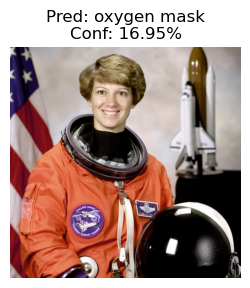

Image 1: True label = person
Predicted class = oxygen mask
Confidence = 16.95%
--------------------------------------------------


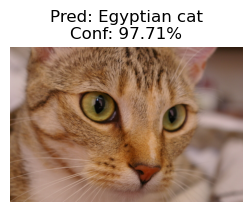

Image 2: True label = cat
Predicted class = Egyptian cat
Confidence = 97.71%
--------------------------------------------------


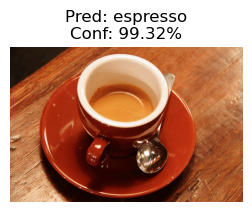

Image 3: True label = cup
Predicted class = espresso
Confidence = 99.32%
--------------------------------------------------


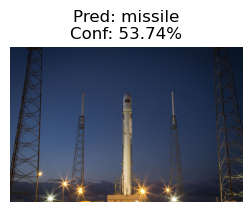

Image 4: True label = rocket
Predicted class = missile
Confidence = 53.74%
--------------------------------------------------


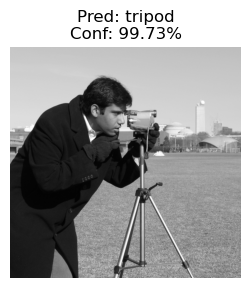

Image 5: True label = photographer
Predicted class = tripod
Confidence = 99.73%
--------------------------------------------------


In [24]:
results = []
for i, (img, item) in enumerate(zip(images, image_data)):
    pred_class, conf = predict(img)
    results.append({
        "true_label": item["true_label"],
        "predicted_class": pred_class,
        "confidence": conf
    })

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Pred: {pred_class}\nConf: {conf:.2%}")
    plt.show()

    print(f"Image {i+1}: True label = {item['true_label']}")
    print(f"Predicted class = {pred_class}")
    print(f"Confidence = {conf:.2%}")
    print("-"*50)

In [26]:
for r in results:
    r["correct"] = r["true_label"].lower() in r["predicted_class"].lower()

df = pd.DataFrame(results)
df

,true_label,predicted_class,confidence,correct
0,person,oxygen mask,0.169511,False
1,cat,Egyptian cat,0.977130,True
2,cup,espresso,0.993199,False
3,rocket,missile,0.537394,False
4,photographer,tripod,0.997287,False


In [28]:
accuracy = df["correct"].mean() * 100
print(f"Overall accuracy on sample set: {accuracy:.1f}%")

Overall accuracy on sample set: 20.0%
